In [30]:
import torch
import pprint
import numpy as np

from tqdm import tqdm
from src.util.celano_lab_scripts import process_image
from src.datasets.mos2_sef import MOS2SEFDataset, Formulation
from src.models.our_method.swin_cafm import SwinCAFM
from src.models.our_method.older_surrogate import MultiHeadOlderSurrogate

# p(y_char | y_hat)
surrogate_weights = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/e. surrogate standalone train-runs/2025-02-12_10-49-50_older_surrogate_mh-VGG-l[-2]+layernorm-adamW-lr=1e-4-augs=True-iii/older_surrogate_mh-VGG-l[-2]+layernorm-adamW-lr=1e-4-augs=True-iii_best_older_surrogate.pth"
surrogate = torch.load(surrogate_weights).cuda().float()

# p(y | y_sparse)
model_weights = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/y-task-formulations/p(y | y_sparse)/a. train-runs/2025-02-12_15-18-22_swinir-loss=OLDER-Perceptual-VGG-aug=F-Multi-Layer+L1(raw-out, y)-lambda=1e-3/swinir-loss=OLDER-Perceptual-VGG-aug=F-Multi-Layer+L1(raw-out, y)-lambda=1e-3_best.pth"
model = torch.load(model_weights).cuda().float()

model.train()
surrogate.eval()

formulation = Formulation.P_Y_BAR_Y_SPARSE
train_dataset = MOS2SEFDataset("train", formulation, 128, 1, 2000)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
val_dataset = MOS2SEFDataset("val", formulation, 128, 1, 2000)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

optimizer = torch.optim.Adam(model.parameters())

IMG_SIZE_UM=2.0
values = {}

Xs = []; ys = []

@torch.no_grad()
def sample():
    
    for i, data in tqdm(enumerate(train_dataloader), total=len(train_dataloader)):
        
        y = data['y'].cuda().float()
        mask = data['mask'].cuda().float()
        y_sparse = (mask * y).cuda().float()
        y_hat = model(y_sparse).cuda().float()
        
        # older_pred = surrogate(y/y_hat)
        # char_gt = surrogate(y); char_pred = surrogate(y_hat)
        
        y_char = process_image(y, 2.0)
        y_hat_char = process_image(y_hat, 2.0)
        y_char_arr = []
        y_hat_char_arr = []
        
        for k, v in y_char.items():
            y_char_arr.append(v)
        
        for k, v in y_hat_char.items():
            y_hat_char_arr.append(v)
            
        y_char_arr = np.array(y_char_arr)
        y_hat_char_arr = np.array(y_hat_char_arr)
        
        # pred - og
        diffs = y_hat_char_arr - y_char_arr

        l1 = torch.nn.functional.l1_loss(y, y_hat)
        
        X_arr = diffs
        y_arr = l1.detach().cpu().numpy()
        
        Xs.append(X_arr)
        ys.append(y_arr)
                      
sample()

/tmp/ipykernel_1489814/928444911.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  surrogate = torch.load(surrogate_weights).cuda().float()
/tmp/ipykernel_1489814/9284449

# [Training Set] OLDER-L1 Feature Correlation
---

In [31]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.utils import resample  # for creating bootstrap samples

# -------------------------------------------------------
# 1. Pretend these are your collected surrogate features & L1 losses
#    X.shape => (N, 9)
#    y.shape => (N,)
# -------------------------------------------------------
# For illustration, let's assume you already have Xs, ys as lists or arrays.
# Convert them to NumPy:
Xs = np.array(Xs).squeeze()
ys = np.array(ys).squeeze()

X = Xs
y = ys

# -------------------------------------------------------
# 2. Split into train/test to evaluate model performance
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------------------------------
# 3. Apply Bootstrapping
#    We'll run multiple iterations; each time we sample a new
#    bootstrap dataset from (X_train, y_train), train a random forest,
#    and record feature importances and MAE on the held-out test.
# -------------------------------------------------------
n_iterations = 50
all_importances = []
all_mae = []

for i in range(n_iterations):
    # Create a bootstrap sample from the original training set
    X_train_bs, y_train_bs = resample(X_train, y_train, random_state=40 + i)

    # Train a simple Random Forest Regressor on this bootstrap sample
    rf_model = RandomForestRegressor(
        n_estimators=100,
        random_state=40 + i,
        # By default, "bootstrap=True", so each tree is also trained on a bootstrap of X_train_bs
    )
    rf_model.fit(X_train_bs, y_train_bs)

    # Evaluate performance on the same test set
    y_pred = rf_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    all_mae.append(mae)

    # Store feature importances
    importances = rf_model.feature_importances_
    all_importances.append(importances)

# Convert to arrays for easier math
all_importances = np.array(all_importances)  # shape = (n_iterations, 9)
all_mae = np.array(all_mae)  # shape = (n_iterations,)

# -------------------------------------------------------
# 4. Compute Average & Std of MAE and Feature Importances
# -------------------------------------------------------
mean_mae = np.mean(all_mae)
std_mae = np.std(all_mae)

mean_importances = np.mean(all_importances, axis=0)
std_importances = np.std(all_importances, axis=0)

# Print results
print(f"Bootstrapped Mean Test MAE: {mean_mae:.4f} ± {std_mae:.4f}")

print("Feature Importances (mean ± std):")
for idx, (m, s) in enumerate(zip(mean_importances, std_importances)):
    print(f"  Feature {idx+1}: {m:.4f} ± {s:.4f}")

Bootstrapped Mean Test MAE: 0.0020 ± 0.0000
Feature Importances (mean ± std):
  Feature 1: 0.1476 ± 0.0129
  Feature 2: 0.1818 ± 0.0124
  Feature 3: 0.1318 ± 0.0110
  Feature 4: 0.0550 ± 0.0083
  Feature 5: 0.1490 ± 0.0112
  Feature 6: 0.0848 ± 0.0052
  Feature 7: 0.0124 ± 0.0037
  Feature 8: 0.0324 ± 0.0081
  Feature 9: 0.2053 ± 0.0125


# [Validation Set] OLDER-L1 Feature Correlation
---

In [32]:
Xs = []; ys = []
@torch.no_grad()

def sample():
    for i, data in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
        y = data['y'].cuda().float()
        mask = data['mask'].cuda().float()
        y_sparse = (mask * y).cuda().float()
        y_hat = model(y_sparse).cuda().float()
        # older_pred = surrogate(y/y_hat)
        # char_gt = surrogate(y); char_pred = surrogate(y_hat)
        y_char = process_image(y, 2.0)
        y_hat_char = process_image(y_hat, 2.0)
        y_char_arr = []
        y_hat_char_arr = []
        for k, v in y_char.items():
            y_char_arr.append(v)
        for k, v in y_hat_char.items():
            y_hat_char_arr.append(v)
        y_char_arr = np.array(y_char_arr)
        y_hat_char_arr = np.array(y_hat_char_arr)
        # pred - og
        diffs = y_hat_char_arr - y_char_arr
        l1 = torch.nn.functional.l1_loss(y, y_hat)
        X_arr = diffs
        y_arr = l1.detach().cpu().numpy()
        Xs.append(X_arr)
        ys.append(y_arr)
                      
sample()

100%|██████████| 2000/2000 [03:42<00:00,  9.01it/s]


In [33]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.utils import resample  # for creating bootstrap samples

# -------------------------------------------------------
# 1. Pretend these are your collected surrogate features & L1 losses
#    X.shape => (N, 9)
#    y.shape => (N,)
# -------------------------------------------------------
# For illustration, let's assume you already have Xs, ys as lists or arrays.
# Convert them to NumPy:
Xs = np.array(Xs).squeeze()
ys = np.array(ys).squeeze()

X = Xs
y = ys

# -------------------------------------------------------
# 2. Split into train/test to evaluate model performance
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------------------------------
# 3. Apply Bootstrapping
#    We'll run multiple iterations; each time we sample a new
#    bootstrap dataset from (X_train, y_train), train a random forest,
#    and record feature importances and MAE on the held-out test.
# -------------------------------------------------------
n_iterations = 50
all_importances = []
all_mae = []

for i in range(n_iterations):
    # Create a bootstrap sample from the original training set
    X_train_bs, y_train_bs = resample(X_train, y_train, random_state=40 + i)

    # Train a simple Random Forest Regressor on this bootstrap sample
    rf_model = RandomForestRegressor(
        n_estimators=100,
        random_state=40 + i,
        # By default, "bootstrap=True", so each tree is also trained on a bootstrap of X_train_bs
    )
    rf_model.fit(X_train_bs, y_train_bs)

    # Evaluate performance on the same test set
    y_pred = rf_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    all_mae.append(mae)

    # Store feature importances
    importances = rf_model.feature_importances_
    all_importances.append(importances)

# Convert to arrays for easier math
all_importances = np.array(all_importances)  # shape = (n_iterations, 9)
all_mae = np.array(all_mae)  # shape = (n_iterations,)

# -------------------------------------------------------
# 4. Compute Average & Std of MAE and Feature Importances
# -------------------------------------------------------
mean_mae = np.mean(all_mae)
std_mae = np.std(all_mae)

mean_importances = np.mean(all_importances, axis=0)
std_importances = np.std(all_importances, axis=0)

# Print results
print(f"Bootstrapped Mean Test MAE: {mean_mae:.4f} ± {std_mae:.4f}")

print("Feature Importances (mean ± std):")
for idx, (m, s) in enumerate(zip(mean_importances, std_importances)):
    print(f"  Feature {idx+1}: {m:.4f} ± {s:.4f}")

Bootstrapped Mean Test MAE: 0.0018 ± 0.0000
Feature Importances (mean ± std):
  Feature 1: 0.0969 ± 0.0158
  Feature 2: 0.1786 ± 0.0187
  Feature 3: 0.0878 ± 0.0112
  Feature 4: 0.0545 ± 0.0098
  Feature 5: 0.1596 ± 0.0155
  Feature 6: 0.1001 ± 0.0116
  Feature 7: 0.0105 ± 0.0019
  Feature 8: 0.0237 ± 0.0041
  Feature 9: 0.2882 ± 0.0294


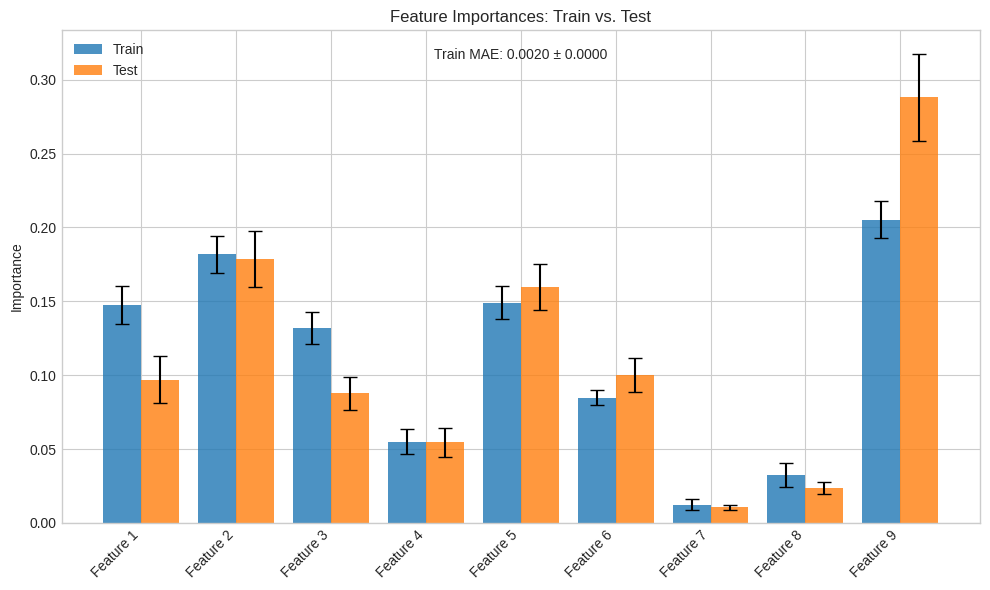

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define your data
features = [
    "Feature 1", "Feature 2", "Feature 3", "Feature 4",
    "Feature 5", "Feature 6", "Feature 7", "Feature 8", "Feature 9"
]

# Train split (mean ± std)
train_means = [0.1476, 0.1818, 0.1318, 0.0550, 0.1490, 0.0848, 0.0124, 0.0324, 0.2053]
train_stds  = [0.0129, 0.0124, 0.0110, 0.0083, 0.0112, 0.0052, 0.0037, 0.0081, 0.0125]

# Test split (mean ± std)
test_means = [0.0969, 0.1786, 0.0878, 0.0545, 0.1596, 0.1001, 0.0105, 0.0237, 0.2882]
test_stds  = [0.0158, 0.0187, 0.0112, 0.0098, 0.0155, 0.0116, 0.0019, 0.0041, 0.0294]

# Step 2: Set up the figure
plt.figure(figsize=(10, 6))
x = np.arange(len(features))
width = 0.4

# Step 3: Plot bars for Train and Test
plt.bar(
    x - width/2, train_means, 
    yerr=train_stds, 
    width=width, 
    label='Train', 
    alpha=0.8, 
    capsize=5
)

plt.bar(
    x + width/2, test_means, 
    yerr=test_stds, 
    width=width, 
    label='Test', 
    alpha=0.8, 
    capsize=5
)

# Step 4: Customize plot appearance
plt.xticks(x, features, rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Feature Importances: Train vs. Test")
plt.legend()

# Optional: Add MAE annotation
train_mae_text = "Train MAE: 0.0020 ± 0.0000"
plt.text(0.5, 0.95, train_mae_text, ha='center', va='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()